Using device: cuda
Loading perturbation level datasets...
Loaded perturb_level 0.01: 1200 samples, 77 features
Detected 6 classes: ['anydesk' 'facebook' 'gmail' 'googledrive' 'instagram' 'telegram']
Loaded perturb_level 0.05: 1200 samples, 77 features
Loaded perturb_level 0.1: 1200 samples, 77 features
Loaded perturb_level 0.2: 1200 samples, 77 features
Loaded perturb_level 0.5: 1200 samples, 77 features

Successfully loaded 5 perturbation levels
Input length: 77
Number of classes: 6

Loaded initial CNN model
Class counts: [200. 200. 200. 200. 200. 200.]
Calculated class weights: [1. 1. 1. 1. 1. 1.]

EVALUATING BASE CNN MODEL (6 CLASSES) ON ALL PERTURBATION LEVELS

Evaluating Perturbation Level: 0.01
--------------------------------------------------
Test Loss:     0.5049
Accuracy:      0.8233
Precision:     0.8317
Recall:        0.8233
F1 Score:      0.8247
Samples:       1200

Evaluating Perturbation Level: 0.05
--------------------------------------------------
Test Loss:     1.7908

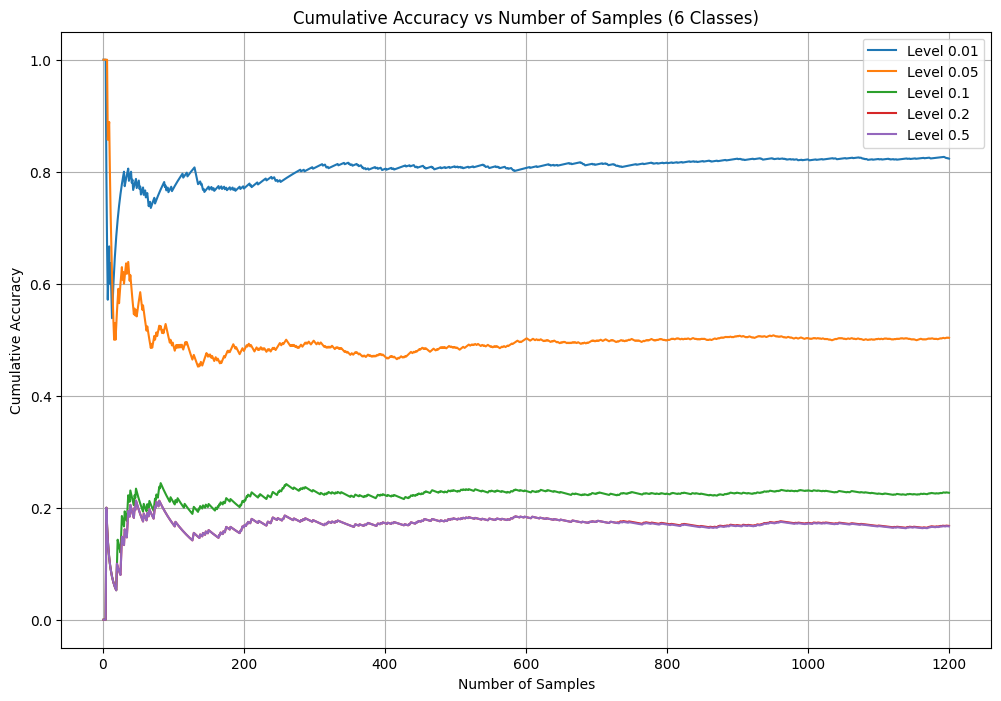


Cumulative accuracy plot saved to: Results/cumulative_accuracy_plot.png


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import os
import matplotlib.pyplot as plt

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define 1D-CNN model (same as original)
class CNN1D(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN1D, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        self.flatten = nn.Flatten()
        output_length = input_length // 8
        self.dense_layers = nn.Sequential(
            nn.Linear(256 * output_length, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)  # تعداد کلاس‌ها پویا است
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.flatten(x)
        x = self.dense_layers(x)
        return x

# Load perturbation level data
def load_perturbation_data(base_path='Dataset', attack_type='FGSM', test_perturb_levels=[0.01, 0.05, 0.1, 0.2, 0.5]):
    """
    Load all perturbation level datasets and return a dictionary of loaders
    Detects number of classes automatically from the first loaded dataset.
    """
    if not os.path.exists(base_path):
        print(f"Error: Data directory '{base_path}' not found.")
        return None

    all_results = {}
    label_encoder = None
    scaler = None
    num_classes = None
    input_length = None

    print("Loading perturbation level datasets...")
    for i, perturb_level in enumerate(test_perturb_levels):
        try:
            # Load the specific perturbation level dataset
            df = pd.read_csv(f'{base_path}/{attack_type}/{attack_type}_eps_{perturb_level}.csv')
            X_test = df.iloc[:, :-1].values
            y_test = df.iloc[:, -1].values
            
            print(f"Loaded perturb_level {perturb_level}: {X_test.shape[0]} samples, {X_test.shape[1]} features")
            
            # First time: fit encoder and scaler
            if label_encoder is None:
                label_encoder = LabelEncoder()
                y_test_encoded = label_encoder.fit_transform(y_test)
                num_classes = len(label_encoder.classes_)
                
                # Check if number of classes is reasonable (e.g., > 1)
                if num_classes < 2:
                    print(f"Error: Expected at least 2 classes, found {num_classes} classes.")
                    return None
                    
                scaler = StandardScaler()
                X_test_scaled = scaler.fit_transform(X_test)
                input_length = X_test.shape[1]
                
                print(f"Detected {num_classes} classes: {label_encoder.classes_}")
            else:
                # Subsequent times: transform only
                y_test_encoded = label_encoder.transform(y_test)
                X_test_scaled = scaler.transform(X_test)
            
            # Convert to tensors
            X_test_tensor = torch.FloatTensor(X_test_scaled).unsqueeze(1).to(device)
            y_test_tensor = torch.LongTensor(y_test_encoded).to(device)
            
            # Create dataset and loader
            test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
            test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
            
            all_results[perturb_level] = {
                'loader': test_loader,
                'num_samples': X_test.shape[0],
                'y_true_original': y_test # Keep original labels for debugging if needed
            }
        except FileNotFoundError:
            print(f"Warning: File not found for perturb_level {perturb_level}, skipping...")
            continue
        except Exception as e:
            print(f"Error loading perturb_level {perturb_level}: {e}")
            continue

    print(f"\nSuccessfully loaded {len(all_results)} perturbation levels")
    print(f"Input length: {input_length}")
    print(f"Number of classes: {num_classes}")
    
    return all_results, num_classes, input_length, label_encoder, scaler

def calculate_class_weights(num_classes, dataset_loader=None):
    """
    Calculate class weights. If dataset_loader is provided, it calculates based on actual distribution.
    Otherwise, assumes uniform weights (1.0).
    """
    if dataset_loader is None:
        # Default to uniform weights if no distribution info is available
        weights = torch.ones(num_classes).to(device)
        print(f"Using uniform class weights for {num_classes} classes.")
        return weights
    
    # Count samples per class
    class_counts = torch.zeros(num_classes)
    for inputs, labels in dataset_loader:
        for label in labels:
            class_counts[label] += 1
            
    # Calculate weights inversely proportional to frequency
    total_samples = class_counts.sum()
    # Avoid division by zero
    weights = total_samples / (num_classes * class_counts)
    weights = weights.to(device)
    print(f"Class counts: {class_counts.cpu().numpy()}")
    print(f"Calculated class weights: {weights.cpu().numpy()}")
    return weights

# Evaluate model on a specific perturbation level dataset
def evaluate_model_on_level(model, test_loader, class_weights):
    model.eval()
    y_true = []
    y_pred = []
    corrects = []  # List to store 1/0 for each sample
    running_loss = 0.0
    total_samples = 0
    # Use CrossEntropyLoss with calculated weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            total_samples += batch_size

            outputs = model(inputs)
            final_loss = criterion(outputs, labels)
            running_loss += final_loss.item() * batch_size
            _, predicted = torch.max(outputs, 1)

            # Collect per-sample correct (1 or 0)
            batch_corrects = (predicted == labels).cpu().numpy().astype(int).tolist()
            corrects.extend(batch_corrects)

            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    # Use average='weighted' to handle different class sizes appropriately
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    test_loss = running_loss / total_samples

    # Calculate cumulative accuracy
    corrects_np = np.array(corrects)
    cumulative_acc = np.cumsum(corrects_np) / np.arange(1, len(corrects_np) + 1)
    return {
        'Test Loss': test_loss,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }, cumulative_acc

# Main function to load model and evaluate all perturbation levels
def main(attack_type, test_perturb_levels):
    # Define perturb levels to test
    
    # Load all perturbation level datasets
    # Note: We don't specify num_classes here anymore, it's detected
    all_data, num_classes, input_length, label_encoder, scaler = load_perturbation_data(
        attack_type=attack_type, 
        test_perturb_levels=test_perturb_levels
    )
    
    if all_data is None:
        print("Failed to load perturbation data. Exiting.")
        return

    # Load the initial CNN model with dynamically detected num_classes
    cnn_model = CNN1D(input_length, num_classes).to(device)
    try:
        checkpoint = torch.load('Models/initial_cnn_model.pth', map_location=device)
        cnn_model.load_state_dict(checkpoint['model_state_dict'])
        print("\nLoaded initial CNN model")
    except FileNotFoundError:
        print("Error: initial_cnn_model.pth not found in Models/ directory")
        return

    # Calculate class weights based on the first available loader or assume uniform
    # Using the first loader to estimate class distribution if possible
    first_perturb_level = sorted(all_data.keys())[0]
    class_weights = calculate_class_weights(num_classes, all_data[first_perturb_level]['loader'])

    # Evaluate on all perturbation levels
    print("\n" + "="*80)
    print(f"EVALUATING BASE CNN MODEL ({num_classes} CLASSES) ON ALL PERTURBATION LEVELS")
    print("="*80)
    results_table = []
    cumulative_dict = {}  # To store cumulative acc for each level
    max_samples = 0  # To find the max number of samples across levels
    
    for perturb_level, data_info in sorted(all_data.items()):
        print(f"\nEvaluating Perturbation Level: {perturb_level}")
        print("-" * 50)
        results, cumulative_acc = evaluate_model_on_level(
            cnn_model,
            data_info['loader'],
            class_weights
        )
        # Store cumulative
        cumulative_dict[perturb_level] = cumulative_acc
        if len(cumulative_acc) > max_samples:
            max_samples = len(cumulative_acc)
        
        # Store summary results
        results_table.append({
            'Perturbation Level': perturb_level,
            'Test Loss': f"{results['Test Loss']:.4f}",
            'Accuracy': f"{results['Accuracy']:.4f}",
            'Precision': f"{results['Precision']:.4f}",
            'Recall': f"{results['Recall']:.4f}",
            'F1 Score': f"{results['F1 Score']:.4f}",
            'Samples': data_info['num_samples']
        })
        
        # Print results
        print(f"Test Loss:     {results['Test Loss']:.4f}")
        print(f"Accuracy:      {results['Accuracy']:.4f}")
        print(f"Precision:     {results['Precision']:.4f}")
        print(f"Recall:        {results['Recall']:.4f}")
        print(f"F1 Score:      {results['F1 Score']:.4f}")
        print(f"Samples:       {data_info['num_samples']}")

    # Display summary table
    print("\n" + "="*80)
    print("SUMMARY TABLE - BASE CNN MODEL PERFORMANCE")
    print("="*80)
    df_results = pd.DataFrame(results_table)
    print(df_results.to_string(index=False))
    
    # Save summary results to CSV
    if not os.path.exists('Results'):
        os.makedirs('Results')
    df_results.to_csv('Results/base_model_perturbation_results.csv', index=False)
    print(f"\nResults saved to: Results/base_model_perturbation_results.csv")

    # Now, create cumulative accuracy DataFrame
    columns = ['perturb_level'] + [f'cum_acc_{i}' for i in range(1, max_samples + 1)]
    cum_rows = []
    for perturb_level in sorted(cumulative_dict.keys()):
        cum_acc = cumulative_dict[perturb_level]
        # Pad with NaN if shorter
        padded_cum = np.pad(cum_acc, (0, max_samples - len(cum_acc)), constant_values=np.nan)
        row = [perturb_level] + list(padded_cum)
        cum_rows.append(row)
    df_cum = pd.DataFrame(cum_rows, columns=columns)
    df_cum.to_csv('Results/cumulative_accuracy.csv', index=False)
    print(f"\nCumulative accuracy saved to: Results/cumulative_accuracy.csv")

    # Plot cumulative accuracy
    plt.figure(figsize=(12, 8))
    for perturb_level, cum_acc in cumulative_dict.items():
        plt.plot(range(1, len(cum_acc) + 1), cum_acc, label=f'Level {perturb_level}')
    plt.xlabel('Number of Samples')
    plt.ylabel('Cumulative Accuracy')
    plt.title(f'Cumulative Accuracy vs Number of Samples ({num_classes} Classes)')
    plt.legend()
    plt.grid(True)
    plt.savefig('Results/cumulative_accuracy_plot.png')
    plt.show()
    print("\nCumulative accuracy plot saved to: Results/cumulative_accuracy_plot.png")

if __name__ == "__main__":
    test_perturb_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
    attack_type = 'FGSM'
    main(attack_type, test_perturb_levels)

Loading perturbation level datasets...
Loaded perturb_level 0.01: 1200 samples, 77 features
Detected 6 classes: ['anydesk' 'facebook' 'gmail' 'googledrive' 'instagram' 'telegram']
Loaded perturb_level 0.05: 1200 samples, 77 features
Loaded perturb_level 0.1: 1200 samples, 77 features
Loaded perturb_level 0.2: 1200 samples, 77 features
Loaded perturb_level 0.5: 1200 samples, 77 features

Successfully loaded 5 perturbation levels
Input length: 77
Number of classes: 6

Loaded initial CNN model
Class counts: [200. 200. 200. 200. 200. 200.]
Calculated class weights: [1. 1. 1. 1. 1. 1.]

EVALUATING BASE CNN MODEL (6 CLASSES) ON ALL PERTURBATION LEVELS

Evaluating Perturbation Level: 0.01
--------------------------------------------------
Test Loss:     0.4788
Accuracy:      0.8508
Precision:     0.8542
Recall:        0.8508
F1 Score:      0.8510
Samples:       1200

Evaluating Perturbation Level: 0.05
--------------------------------------------------
Test Loss:     1.9934
Accuracy:      0.4

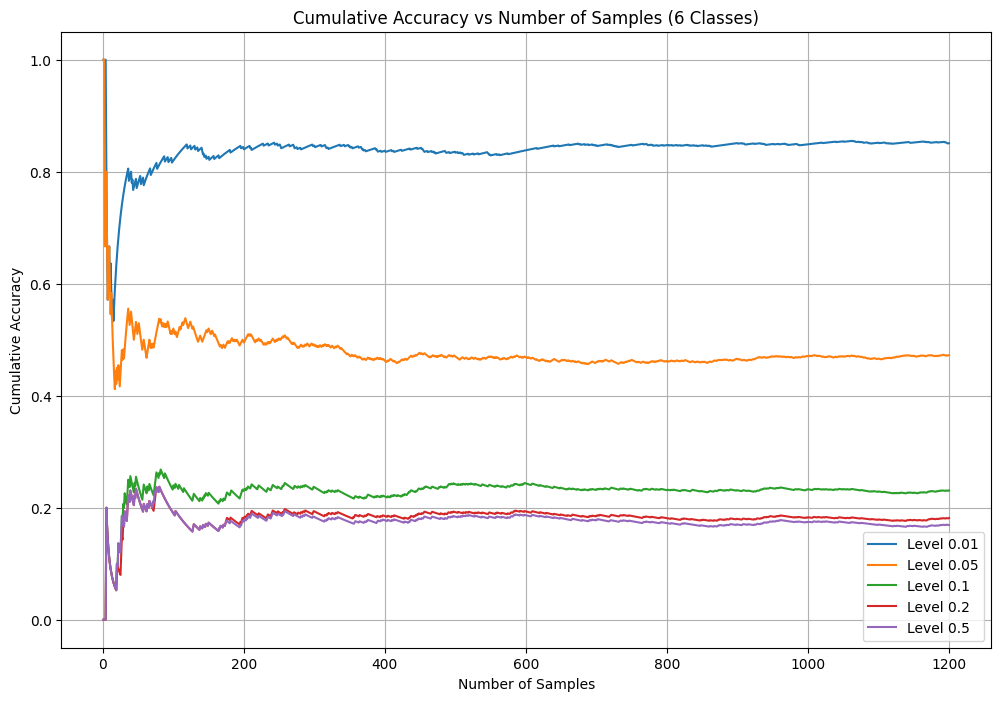


Cumulative accuracy plot saved to: Results/cumulative_accuracy_plot.png


In [2]:
if __name__ == "__main__":
    test_perturb_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
    attack_type = 'PGD'
    main(attack_type, test_perturb_levels)

Loading perturbation level datasets...
Loaded perturb_level 0.1: 1200 samples, 77 features
Detected 6 classes: ['anydesk' 'facebook' 'gmail' 'googledrive' 'instagram' 'telegram']
Loaded perturb_level 0.5: 1200 samples, 77 features
Loaded perturb_level 1.0: 1200 samples, 77 features
Loaded perturb_level 2.0: 1200 samples, 77 features
Loaded perturb_level 5.0: 1200 samples, 77 features

Successfully loaded 5 perturbation levels
Input length: 77
Number of classes: 6

Loaded initial CNN model
Class counts: [200. 200. 200. 200. 200. 200.]
Calculated class weights: [1. 1. 1. 1. 1. 1.]

EVALUATING BASE CNN MODEL (6 CLASSES) ON ALL PERTURBATION LEVELS

Evaluating Perturbation Level: 0.1
--------------------------------------------------
Test Loss:     0.3078
Accuracy:      0.9075
Precision:     0.9074
Recall:        0.9075
F1 Score:      0.9071
Samples:       1200

Evaluating Perturbation Level: 0.5
--------------------------------------------------
Test Loss:     5.6608
Accuracy:      0.6900


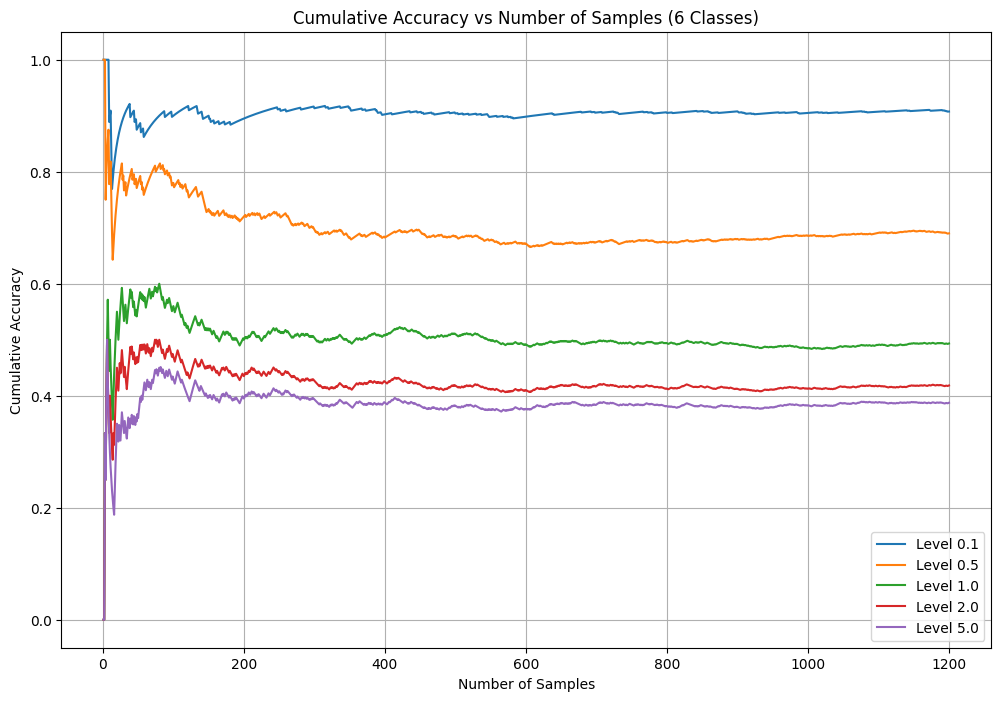


Cumulative accuracy plot saved to: Results/cumulative_accuracy_plot.png


In [3]:
if __name__ == "__main__":
    test_perturb_levels = [0.1, 0.5, 1.0, 2.0, 5.0]
    attack_type = 'CW'
    main(attack_type, test_perturb_levels)

Loading perturbation level datasets...
Loaded perturb_level 0.1: 1200 samples, 77 features
Detected 6 classes: ['anydesk' 'facebook' 'gmail' 'googledrive' 'instagram' 'telegram']
Loaded perturb_level 0.5: 1200 samples, 77 features
Loaded perturb_level 1.0: 1200 samples, 77 features
Loaded perturb_level 2.0: 1200 samples, 77 features
Loaded perturb_level 5.0: 1200 samples, 77 features

Successfully loaded 5 perturbation levels
Input length: 77
Number of classes: 6

Loaded initial CNN model
Class counts: [200. 200. 200. 200. 200. 200.]
Calculated class weights: [1. 1. 1. 1. 1. 1.]

EVALUATING BASE CNN MODEL (6 CLASSES) ON ALL PERTURBATION LEVELS

Evaluating Perturbation Level: 0.1
--------------------------------------------------
Test Loss:     0.6315
Accuracy:      0.8267
Precision:     0.8353
Recall:        0.8267
F1 Score:      0.8277
Samples:       1200

Evaluating Perturbation Level: 0.5
--------------------------------------------------
Test Loss:     1.6886
Accuracy:      0.5442


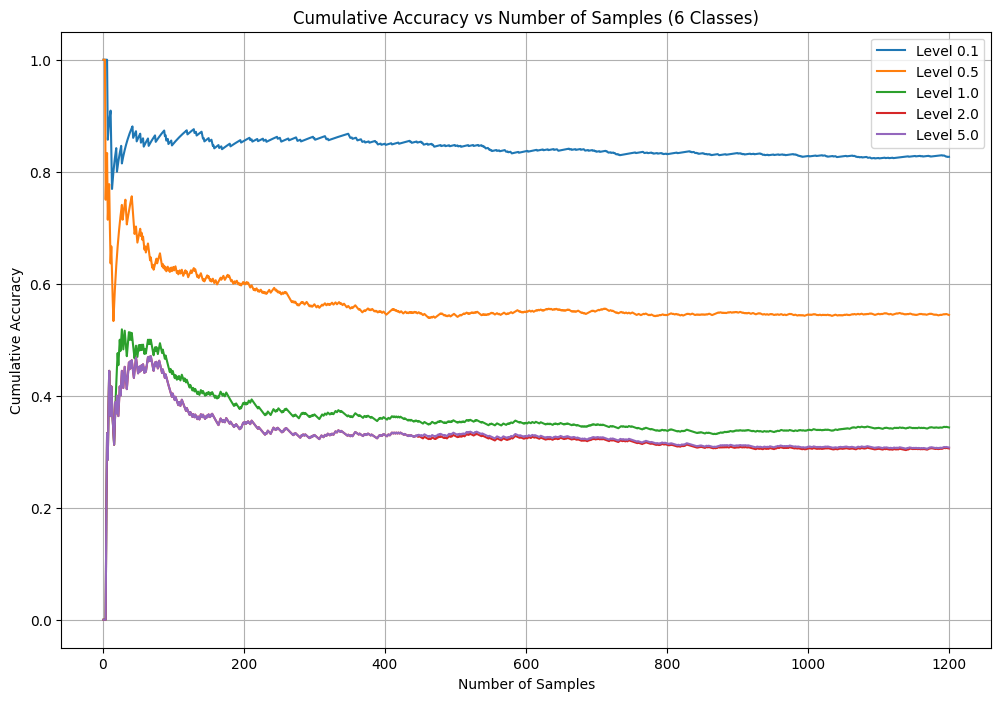


Cumulative accuracy plot saved to: Results/cumulative_accuracy_plot.png


In [4]:
if __name__ == "__main__":
    test_perturb_levels = [0.1, 0.5, 1.0, 2.0, 5.0]
    attack_type = 'DeepFool'
    main(attack_type, test_perturb_levels)